In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ids-intrusion-csv/02-28-2018.csv
/kaggle/input/ids-intrusion-csv/03-01-2018.csv
/kaggle/input/ids-intrusion-csv/02-16-2018.csv
/kaggle/input/ids-intrusion-csv/02-15-2018.csv
/kaggle/input/ids-intrusion-csv/02-21-2018.csv
/kaggle/input/ids-intrusion-csv/03-02-2018.csv
/kaggle/input/ids-intrusion-csv/02-22-2018.csv
/kaggle/input/ids-intrusion-csv/02-20-2018.csv
/kaggle/input/ids-intrusion-csv/02-14-2018.csv
/kaggle/input/ids-intrusion-csv/02-23-2018.csv


In [2]:
!pip -q install lime dill joblib

import os, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras

import dill
from lime.lime_tabular import LimeTabularExplainer

print("TF:", tf.__version__)
print("Pandas:", pd.__version__)


2026-01-01 17:35:44.657909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767288944.887606      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767288944.959880      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767288945.503911      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767288945.503956      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767288945.503958      55 computation_placer.cc:177] computation placer alr

TF: 2.19.0
Pandas: 2.2.2


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import os

# -------------------------------
# 1) Trouver ou télécharger dataset
# -------------------------------
def resolve_data_root():
    # Cas A: Kaggle Notebook avec dataset ajouté via "Add data"
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists() and any(kaggle_input.iterdir()):
        print("[INFO] Dataset détecté via /kaggle/input (Add data).")
        return kaggle_input

    # Cas B: pas de dataset monté -> on tente kagglehub
    print("[WARN] /kaggle/input est vide. Tentative de téléchargement via kagglehub...")
    try:
        import kagglehub
    except ImportError:
        raise ImportError(
            "kagglehub n'est pas installé. Ajoute: !pip -q install kagglehub"
        )

    # Téléchargement (cache local géré par kagglehub)
    path_str = kagglehub.dataset_download("solarmainframe/ids-intrusion-csv")
    data_root = Path(path_str)
    print("[INFO] kagglehub a téléchargé le dataset ici:", data_root)

    # Souvent, les CSV sont dans un sous-dossier : on garde la racine, et on fait rglob
    return data_root

DATA_ROOT = resolve_data_root()

print("\n=== Contenu de DATA_ROOT ===")
print("DATA_ROOT:", DATA_ROOT)
if DATA_ROOT.exists():
    # Affiche quelques éléments (évite d'imprimer 10 000 fichiers)
    items = list(DATA_ROOT.iterdir()) if DATA_ROOT.is_dir() else []
    print("Nb items racine:", len(items))
    for p in items[:20]:
        print(" -", p.name, "(dir)" if p.is_dir() else "(file)")
else:
    raise FileNotFoundError(f"DATA_ROOT introuvable: {DATA_ROOT}")

# -------------------------------
# 2) Détecter CSV/ZIP
# -------------------------------
csv_files = sorted(list(DATA_ROOT.rglob("*.csv")) + list(DATA_ROOT.rglob("*.CSV")))
print("\nCSV trouvés:", len(csv_files))
for p in csv_files[:15]:
    print(" -", p)

# Si aucun CSV, chercher ZIP et dézipper automatiquement
if len(csv_files) == 0:
    zips = sorted(list(DATA_ROOT.rglob("*.zip")) + list(DATA_ROOT.rglob("*.ZIP")))
    print("\n⚠️ Aucun CSV détecté.")
    if zips:
        print("ZIP trouvés:", len(zips))
        for z in zips[:10]:
            print(" -", z)

        import zipfile
        unzip_dir = Path("/kaggle/working/unzipped_ids_intrusion")
        unzip_dir.mkdir(parents=True, exist_ok=True)

        for z in zips:
            with zipfile.ZipFile(z, "r") as zip_ref:
                zip_ref.extractall(unzip_dir)

        print("[INFO] Dézip terminé ->", unzip_dir)
        DATA_ROOT = unzip_dir

        csv_files = sorted(list(DATA_ROOT.rglob("*.csv")) + list(DATA_ROOT.rglob("*.CSV")))
        print("CSV après dézip:", len(csv_files))
        for p in csv_files[:15]:
            print(" -", p)
    else:
        raise ValueError(
            "Aucun CSV/ZIP trouvé. Vérifie que le dataset est correct et accessible.\n"
            "Sur Kaggle notebook, le plus simple est 'Add data'.\n"
            "Avec kagglehub, il faut aussi être authentifié si nécessaire."
        )

if len(csv_files) == 0:
    raise ValueError("Toujours aucun CSV détecté après tentative de dézip.")

# -------------------------------
# 3) Paramètres anti-RAM + fonctions preprocessing
# -------------------------------
CHUNKSIZE = 200_000
MAX_ROWS_TOTAL = 1_000_000  # baisse à 200k si RAM faible
SEED = 42
rng = np.random.default_rng(SEED)

def standardize_columns(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

def find_label_col(df):
    # Ajout de variantes courantes
    for c in ["Label", "label", "Class", "class", "target", "Target", "Attack", "attack", "Category", "category"]:
        if c in df.columns:
            return c
    return None

def clean_numeric(df):
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.fillna(0.0, inplace=True)
    return df

def drop_useless_cols(df):
    drop_candidates = {
        "Flow ID", "Src IP", "Dst IP", "Source IP", "Destination IP",
        "Timestamp", "Time", "Fwd Header Length.1"
    }
    cols = [c for c in df.columns if c in drop_candidates]
    return df.drop(columns=cols, errors="ignore")

def load_sample_csvs(csv_paths, chunksize, max_rows_total):
    collected = []
    collected_rows = 0
    used_files = 0
    skipped_no_label = 0

    for fp in csv_paths:
        # Smoke test rapide
        try:
            head = pd.read_csv(fp, nrows=3, low_memory=False)
            head = standardize_columns(head)
        except Exception as e:
            print(f"[SKIP] Lecture impossible {fp.name} -> {type(e).__name__}: {e}")
            continue

        if find_label_col(head) is None:
            skipped_no_label += 1
            continue

        used_files += 1

        for chunk in pd.read_csv(fp, chunksize=chunksize, low_memory=False):
            chunk = standardize_columns(chunk)

            label_col = find_label_col(chunk)
            if label_col is None:
                continue

            chunk = drop_useless_cols(chunk)
            chunk = clean_numeric(chunk)

            if max_rows_total is None:
                collected.append(chunk)
                continue

            remaining = max_rows_total - collected_rows
            if remaining <= 0:
                break

            take = min(len(chunk), remaining)
            if take < len(chunk):
                idx = rng.choice(len(chunk), size=take, replace=False)
                chunk = chunk.iloc[idx]

            collected.append(chunk)
            collected_rows += len(chunk)

            if collected_rows >= max_rows_total:
                break

        if max_rows_total is not None and collected_rows >= max_rows_total:
            break

    print(f"[INFO] CSV analysés: {len(csv_paths)} | utilisés: {used_files} | ignorés(no label): {skipped_no_label}")
    print(f"[INFO] Lignes collectées: {collected_rows:,}")

    if len(collected) == 0:
        raise ValueError(
            "Aucun chunk collecté.\n"
            "➡️ Vérifie les colonnes des CSV (surtout le nom du label). "
            "Fais un print des colonnes d'un CSV avec pd.read_csv(..., nrows=5)."
        )

    return pd.concat(collected, axis=0, ignore_index=True)

# Charger réellement
df = load_sample_csvs(csv_files, CHUNKSIZE, MAX_ROWS_TOTAL)
df = standardize_columns(df)
label_col = find_label_col(df)

print("\n✅ Shape final df:", df.shape)
print("✅ Label col:", label_col)
print(df[label_col].value_counts().head(10))
print("\nAperçu colonnes:", list(df.columns)[:30])


[INFO] Dataset détecté via /kaggle/input (Add data).

=== Contenu de DATA_ROOT ===
DATA_ROOT: /kaggle/input
Nb items racine: 1
 - ids-intrusion-csv (dir)

CSV trouvés: 10
 - /kaggle/input/ids-intrusion-csv/02-14-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-15-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-16-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-20-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-21-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-22-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-23-2018.csv
 - /kaggle/input/ids-intrusion-csv/02-28-2018.csv
 - /kaggle/input/ids-intrusion-csv/03-01-2018.csv
 - /kaggle/input/ids-intrusion-csv/03-02-2018.csv
[INFO] CSV analysés: 10 | utilisés: 1 | ignorés(no label): 0
[INFO] Lignes collectées: 1,000,000

✅ Shape final df: (1000000, 79)
✅ Label col: Label
Label
0.0    1000000
Name: count, dtype: int64

Aperçu colonnes: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fw

In [4]:
from collections import defaultdict
import numpy as np
import pandas as pd

CHUNKSIZE = 200_000
TARGET_PER_CLASS = 50_000   # ajuste: 20k si RAM faible, 80k si RAM ok
SEED = 42
rng = np.random.default_rng(SEED)

def standardize_columns(df):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

def clean_numeric(df):
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.fillna(0.0, inplace=True)
    return df

def drop_useless_cols(df):
    drop_candidates = {
        "Flow ID", "Src IP", "Dst IP", "Source IP", "Destination IP",
        "Timestamp", "Time", "Fwd Header Length.1"
    }
    cols = [c for c in df.columns if c in drop_candidates]
    return df.drop(columns=cols, errors="ignore")

def load_stratified_sample(csv_paths, label_col="Label", target_per_class=50_000):
    buckets = defaultdict(list)
    counts = defaultdict(int)

    # On boucle sur les fichiers et on prélève par classe jusqu'à atteindre target_per_class
    for fp in csv_paths:
        for chunk in pd.read_csv(fp, chunksize=CHUNKSIZE, low_memory=False):
            chunk = standardize_columns(chunk)
            if label_col not in chunk.columns:
                continue

            # Nettoyage minimal (on garde label intact)
            y = chunk[label_col].astype(str).str.strip()
            X_chunk = chunk.drop(columns=[label_col])
            X_chunk = drop_useless_cols(X_chunk)
            X_chunk = clean_numeric(X_chunk)

            chunk_clean = X_chunk.copy()
            chunk_clean[label_col] = y.values

            # Pour chaque classe présente dans ce chunk, on prélève ce qu’il manque
            for cls in y.unique():
                if counts[cls] >= target_per_class:
                    continue
                cls_rows = chunk_clean[chunk_clean[label_col] == cls]
                need = target_per_class - counts[cls]
                take = min(len(cls_rows), need)
                if take <= 0:
                    continue

                if take < len(cls_rows):
                    cls_rows = cls_rows.sample(n=take, random_state=SEED)

                buckets[cls].append(cls_rows)
                counts[cls] += take

            # condition d’arrêt : toutes les classes vues atteignent target
            # (on s’arrête dès que Benign + attaques principales sont suffisamment présentes)
            if counts.get("Benign", 0) >= target_per_class:
                # si tu veux être strict, tu peux exiger un minimum d’autres classes aussi
                pass

    # Concat final
    dfs = []
    for cls, parts in buckets.items():
        if parts:
            dfs.append(pd.concat(parts, ignore_index=True))
    df_out = pd.concat(dfs, ignore_index=True)

    print("✅ Comptage par classe (échantillon):")
    print(df_out[label_col].value_counts().head(20))
    print("Shape:", df_out.shape)
    return df_out

df_train = load_stratified_sample(csv_files, target_per_class=TARGET_PER_CLASS)


✅ Comptage par classe (échantillon):
Label
Benign                      50000
FTP-BruteForce              50000
SSH-Bruteforce              50000
DoS attacks-SlowHTTPTest    50000
DoS attacks-Hulk            50000
Infilteration               50000
DDOS attack-HOIC            50000
DDoS attacks-LOIC-HTTP      50000
Bot                         50000
DoS attacks-GoldenEye       41508
DoS attacks-Slowloris       10990
DDOS attack-LOIC-UDP         1730
Brute Force -Web              611
Brute Force -XSS              230
SQL Injection                  87
Label                          59
Name: count, dtype: int64
Shape: (505215, 80)


In [5]:
import numpy as np
import pandas as pd

label_col = "Label"

# 1) Supprimer lignes corrompues où la valeur du label = "Label"
mask_bad = df_train[label_col].astype(str).str.strip().str.lower().eq("label")
n_bad = int(mask_bad.sum())
print("Lignes corrompues (Label == 'Label'):", n_bad)

if n_bad > 0:
    df_train = df_train.loc[~mask_bad].copy()

# 2) Reconstruire X/y proprement
df_train[label_col] = df_train[label_col].astype(str).str.strip()

y_raw = df_train[label_col].values
X = df_train.drop(columns=[label_col])

# 3) Garder colonnes numériques, forcer conversion, gérer inf/NaN
X = X.select_dtypes(include=[np.number]).copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Afficher combien de NaN il reste
nan_total = int(X.isna().sum().sum())
nan_cols = X.isna().sum().sort_values(ascending=False)
print("NaN total dans X:", nan_total)
print("Top colonnes avec NaN:")
print(nan_cols.head(10))

# 4) Imputation (zéro) — simple et OK en IDS
X = X.fillna(0.0)

# 5) Vérification finale
print("NaN total après fillna:", int(X.isna().sum().sum()))

# 6) Encoder y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Classes (corrigées):", list(le.classes_)[:20], "... (n=", len(le.classes_), ")")


Lignes corrompues (Label == 'Label'): 59
NaN total dans X: 455853
Top colonnes avec NaN:
Src Port            455156
Flow Pkts/s            516
Flow Byts/s            181
Tot Fwd Pkts             0
Dst Port                 0
Protocol                 0
Flow Duration            0
Fwd Pkt Len Max          0
Fwd Pkt Len Min          0
Fwd Pkt Len Mean         0
dtype: int64
NaN total après fillna: 0
Classes (corrigées): ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce'] ... (n= 15 )


In [6]:
from sklearn.feature_selection import mutual_info_classif

N_FEATURES = 39
mi = mutual_info_classif(X.astype(np.float64).values, y, random_state=SEED)
top_idx = np.argsort(mi)[::-1][:N_FEATURES]
feature_names = X.columns[top_idx].tolist()
X_39 = X[feature_names].astype(np.float64)

print("✅ 39 features sélectionnées (extrait):", feature_names[:10])
print("X_39 shape:", X_39.shape)


✅ 39 features sélectionnées (extrait): ['Flow IAT Max', 'Flow Duration', 'Fwd Pkts/s', 'Flow IAT Mean', 'Flow Pkts/s', 'Init Fwd Win Byts', 'Fwd IAT Tot', 'Fwd IAT Max', 'Dst Port', 'Bwd Pkts/s']
X_39 shape: (505156, 39)


Classes détectées : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Train: (404124, 39) Test: (101032, 39)

Training Random Forest...

Macro F1-score: 0.9112839322513264

Classification report:

              precision    recall  f1-score   support

           0     0.8387    0.8160    0.8272     10000
           1     0.9999    1.0000    1.0000     10000
           2     0.9630    0.8525    0.9043       122
           3     1.0000    0.9348    0.9663        46
           4     0.9999    0.9999    0.9999     10000
           5     1.0000    1.0000    1.0000       346
           6     0.9999    0.9998    0.9998     10000
           7     1.0000    0.9999    0.9999      8302
           8     0.9998    1.0000    0.9999     10000
           9     0.8196    0.5178    0.6346     10000
          10     1.0000    0.9995    0.9998      2198
          11     0.6476    0.8861    0.7483     10000
          12     0.8208    0.8444    0.8325     10000
          13     0.7368    0.7778    0.7568      

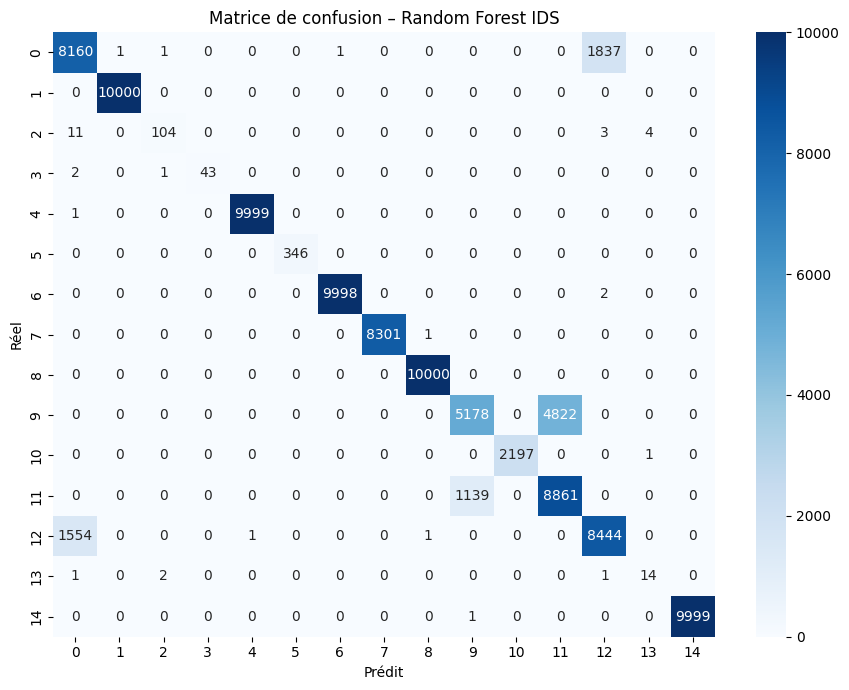

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


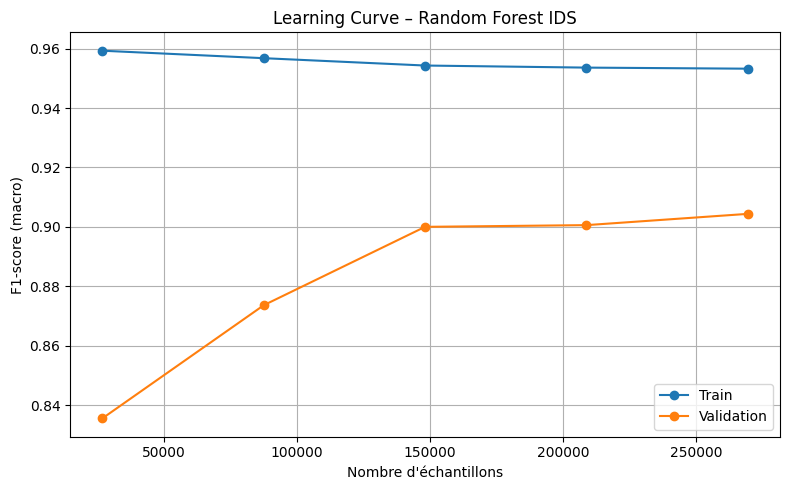

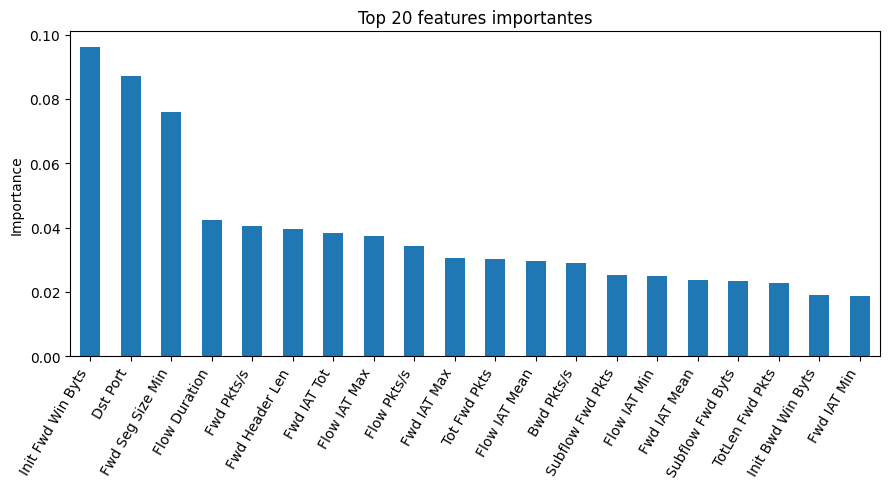

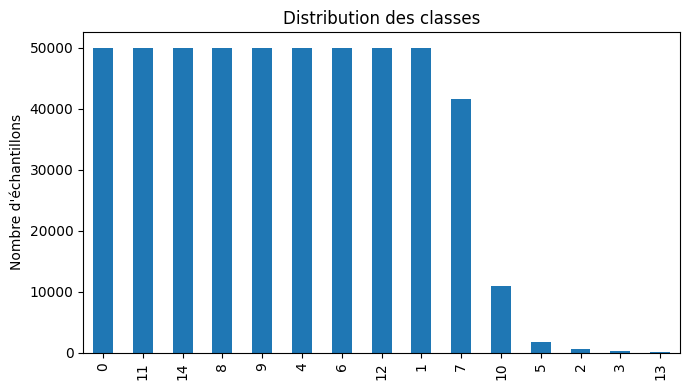


 Entraînement terminé
📁 Figures sauvegardées dans : /kaggle/working/output_figures


In [7]:
# ============================================================
# RANDOM FOREST IDS — TRAIN + STATS + FIGURES SAUVEGARDÉES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SEED = 42

# ============================================================
#  DOSSIER DE SORTIE
# ============================================================

OUT_DIR = Path("/kaggle/working/output_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SPLIT TRAIN / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_39,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

labels = np.unique(y)

print("Classes détectées :", labels)
print("Train:", X_train.shape, "Test:", X_test.shape)

# ============================================================
# ENTRAÎNEMENT RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=SEED,
    class_weight="balanced_subsample"
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)

# ============================================================
# ÉVALUATION
# ============================================================

y_pred = rf.predict(X_test)

print("\nMacro F1-score:", f1_score(y_test, y_pred, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

# ============================================================
#  MATRICE DE CONFUSION
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion – Random Forest IDS")
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=300)
plt.show()

# ============================================================
# LEARNING CURVE
# ============================================================

sizes, train_scores, val_scores = learning_curve(
    rf,
    X_train,
    y_train,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, val_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Nombre d'échantillons")
plt.ylabel("F1-score (macro)")
plt.title("Learning Curve – Random Forest IDS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "learning_curve.png", dpi=300)
plt.show()

# ============================================================
# IMPORTANCE DES FEATURES
# ============================================================

importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9,5))
importances.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Top 20 features importantes")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", dpi=300)
plt.show()

# ============================================================
#  DISTRIBUTION DES CLASSES
# ============================================================

class_counts = pd.Series(y).value_counts()

plt.figure(figsize=(7,4))
class_counts.plot(kind="bar")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des classes")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=300)
plt.show()

# ============================================================
#  FIN
# ============================================================

print("\n Entraînement terminé")
print(" Figures sauvegardées dans :", OUT_DIR)


Rows Benign pour AE: 50000


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 39)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,855 (112.71 KB)

 Trainable params: 28,855 (112.71 KB)

 Non-trainable params: 0 (0.00 B)

Training Autoencoder...
Epoch 1/30
22/22 - 4s - 167ms/step - loss: 0.9370 - val_loss: 0.9998 - learning_rate: 1.0000e-03
Epoch 2/30
22/22 - 0s - 7ms/step - loss: 0.6685 - val_loss: 0.7167 - learning_rate: 1.0000e-03
Epoch 3/30
22/22 - 0s - 6ms/step - loss: 0.4826 - val_loss: 0.5589 - learning_rate: 1.0000e-03
Epoch 4/30
22/22 - 0s - 6ms/step - loss: 0.3352 - val_loss: 0.3559 - learning_rate: 1.0000e-03
Epoch 5/30
22/22 - 0s - 6ms/step - loss: 0.2090 - val_loss: 0.2371 - learning_rate: 1.0000e-03
Epoch 6/30
22/22 - 0s - 6ms/step - loss: 0.1277 - val_loss: 0.1153 - learning_rate: 1.0000e-03
Epoch 7/30
22/22 - 0s - 6ms/step - loss: 0.0878 - val_loss: 0.0844 - learning_rate: 1.0000e-03
Epoch 8/30
22/22 - 0s - 6ms/step - loss: 0.0972 - val_loss: 0.0657 - learning_rate: 1.0000e-03
Epoch 9/30
22/22 - 0s - 6ms/step - loss: 0.0820 - val_loss: 0.0753 - learning_rate: 1.0000e-03
Epoch 10/30
22/22 - 0s - 6ms/step - loss: 0.1037 - val_loss: 0.0752 - learning_rate: 1.0000e-03
Epoch 11/30
22/22 - 0s 

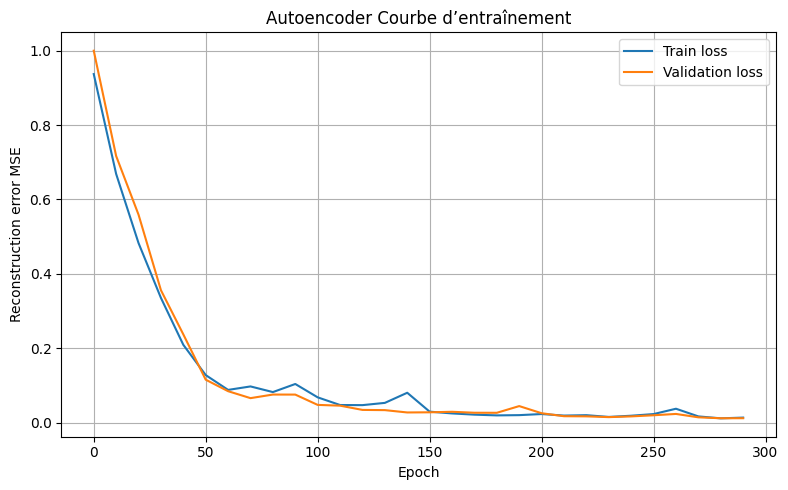

✅ Courbe AE sauvegardée : /kaggle/working/output_figures/autoencoder_training_curve.png


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# ============================================================
#  Dossier de sortie pour figures
# ============================================================

OUT_DIR = Path("/kaggle/working/output_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Sélection des flux BENIGN pour l’Autoencoder
# ============================================================

benign_class = None
for cls in le.classes_:
    if cls.lower() == "benign":
        benign_class = cls
        break

if benign_class is None:
    print("[WARN] 'Benign' non trouvé -> AE entraîné sur tout")
    X_ae = X_39.values
else:
    benign_idx = np.where(le.classes_ == benign_class)[0][0]
    X_ae = X_39.values[y == benign_idx]
    print("Rows Benign pour AE:", X_ae.shape[0])

# ============================================================
# Prétraitement (StandardScaler)
# ============================================================

preprocess = Pipeline([
    ("scaler", StandardScaler())
])

from sklearn.model_selection import train_test_split
X_train_ae, X_val_ae = train_test_split(
    X_ae,
    test_size=0.1,
    random_state=SEED
)

X_train_scaled = preprocess.fit_transform(X_train_ae)
X_val_scaled = preprocess.transform(X_val_ae)

# ============================================================
# Construction de l’Autoencoder
# ============================================================

def build_autoencoder(input_dim, lr=1e-3):
    inp = keras.Input(shape=(input_dim,))
    x = keras.layers.Dense(128, activation="relu")(inp)
    x = keras.layers.Dense(64, activation="relu")(x)
    bottleneck = keras.layers.Dense(16, activation="relu", name="bottleneck")(x)
    x = keras.layers.Dense(64, activation="relu")(bottleneck)
    x = keras.layers.Dense(128, activation="relu")(x)
    out = keras.layers.Dense(input_dim, activation="linear")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

ae = build_autoencoder(N_FEATURES, lr=1e-3)
ae.summary()

# ============================================================
#  Callbacks (IDS-friendly)
# ============================================================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

# ============================================================
# Entraînement
# ============================================================

print("Training Autoencoder...")
history = ae.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=300,
    batch_size=1024,
    shuffle=True,
    callbacks=callbacks,
    verbose=2
)

# ============================================================
# COURBE D’ENTRAÎNEMENT (LOSS) 
# ============================================================

epochs = np.arange(len(history.history["loss"]))
epochs_display = epochs * 10  

plt.figure(figsize=(8,5))
plt.plot(epochs_display, history.history["loss"], label="Train loss")
plt.plot(epochs_display, history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction error MSE")
plt.title("Autoencoder Courbe d’entraînement")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(OUT_DIR / "autoencoder_training_curve.png", dpi=300)
plt.show()

print("Courbe AE sauvegardée :", OUT_DIR / "autoencoder_training_curve.png")


In [11]:
import json, pickle
import joblib
from pathlib import Path

OUT_DIR = Path("/kaggle/working/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / "model.pkl", "wb") as f:
    pickle.dump(rf, f)

ae.save(OUT_DIR / "autoencoder_39ft.hdf5")

joblib.dump(preprocess, OUT_DIR / "preprocess_pipeline_AE_39ft.save")

(OUT_DIR / "feature_names.json").write_text(json.dumps(feature_names, indent=2))

print(" Export terminé. Fichiers générés :")
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)


 Export terminé. Fichiers générés :
 - autoencoder_39ft.hdf5
 - feature_names.json
 - model.pkl
 - preprocess_pipeline_AE_39ft.save
